- 각 변수는 어떤 값을 갖는가?
- 각 품종의 데이터 수는 동일한가?
- 꽃잎과 꽃받침의 크기는 어떻게 분포하는가?
- 이상치로 보이는 관측값은 존재하는가?
- 꽃잎 길이와 너비는 서로 어떠한 관계를 갖는가?
- 품종에 따라 측정값의 분포가 다른가?
- 여러 수치형 변수 중 어떤 변수들이 강한 관계를 갖는가?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [2]:
sns.set_theme(
    context='notebook',
    style='whitegrid',
)

In [3]:
iris = load_iris(as_frame=True)
iris

{'data':      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                  5.1               3.5                1.4               0.2
 1                  4.9               3.0                1.4               0.2
 2                  4.7               3.2                1.3               0.2
 3                  4.6               3.1                1.5               0.2
 4                  5.0               3.6                1.4               0.2
 ..                 ...               ...                ...               ...
 145                6.7               3.0                5.2               2.3
 146                6.3               2.5                5.0               1.9
 147                6.5               3.0                5.2               2.0
 148                6.2               3.4                5.4               2.3
 149                5.9               3.0                5.1               1.8
 
 [150 rows x 4 columns],
 'target': 0     

In [5]:
df=iris.frame.copy()

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')

In [8]:
df= df.rename(
    columns={
        'sepal length (cm)': 'sepal_length',
        'sepal width (cm)': 'sepal_width',
        'petal length (cm)': 'petal_length',
        'petal width (cm)': 'petal_width'
    }
)
df
df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [9]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [10]:
dict(enumerate(iris.target_names))
## 순서값을 가짐 순서값을 매핑 필드는 변수 0-1-3...


{0: np.str_('setosa'), 1: np.str_('versicolor'), 2: np.str_('virginica')}

In [14]:
target_map = dict(enumerate(iris.target_names))
df['species']= df['target'].map(target_map)
df= df.drop(columns='target')


In [13]:
df.shape

(150, 6)

In [15]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [17]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [18]:
numeric_columns = df.select_dtypes(include='number').columns.to_list()
print(type(numeric_columns))
print(numeric_columns)

<class 'list'>
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


In [19]:
categorical_columns = df.select_dtypes(exclude='number').columns.to_list()
print(type(categorical_columns))
print(categorical_columns)

<class 'list'>
['species']


In [20]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [21]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [23]:
df.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [ ]:
## 꽃잎 길이는 어떤 분포를 갖고 있는가?
# -사용할 변수 : petal_length

## 품종마다 꽃잎 길이가 다른가?
# -사용할 변수: species, petal_length

## 꽃잎 길이와 꽃잎 너비사이에 관계가 있는가?
# 사용할 변수: petal_length, petal_width

## 꽃잎 길이와 너비의 관계가 품종에 따라 다르게 나타나는가?
# 사용할 변수: petal_length, petal_width, species

## 네가지 수치형 변수 전체에서는 어떤 관계가 나타나는가?
# -사용할 변수: 모든 수치형 변수

## 단변량 변수
수치형 변수
-중심의 위치
-전체의 범위
-분포의 모양
-값이 집중된 영역
-극단적으로 떨어진 관측값

In [28]:
df['petal_length'].describe().round(2)

count    150.00
mean       3.76
std        1.77
min        1.00
25%        1.60
50%        4.35
75%        5.10
max        6.90
Name: petal_length, dtype: float64

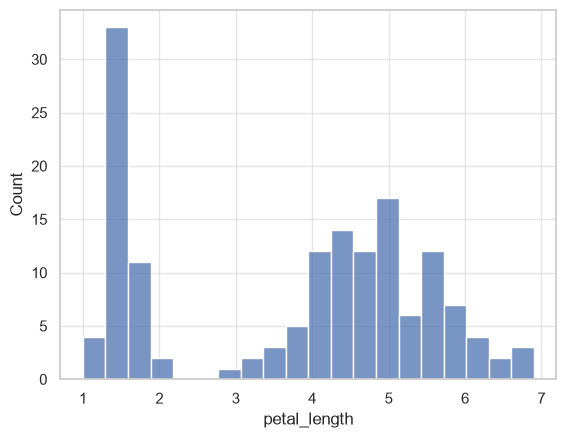

In [27]:
sns.histplot(
    data=df,
    x='petal_length',
    bins=20
)
plt.show()

### KDE(kernel Density Estimation)
KED(커널 밀도 추정)는 수집한 데이터의 분포를 매끄러운 곡선 형태로 추정하여 나타내는
통계헉적 방법, 히스토그램의 단점을 보완한 매끄러운 확률 밀도 그래프

히스토그램 구간의 경계 위치나 너비를 어떻게 설정하느냐에 따라서 그래프의 모양이 달라진다. 연속적인 데이터의 흐름을 반영하기가 어렵다.

### 커널(kernel)
하나의 데이터 포인트를 대표하는 원형 형태의 작은 함수(곡선)을 의미한다.
데이터 포인트 하나가 관측되었을 때 이 값 근처에도 유사한 값이 존재할 확률이 높다라는 것을 나타내기 위한 확률 분포 곡선


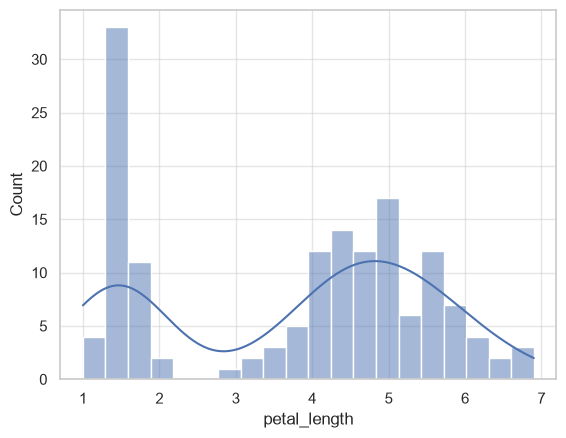

In [30]:
sns.histplot(
    data=df,
    x='petal_length',
    bins=20,
    kde=True
)
plt.show()

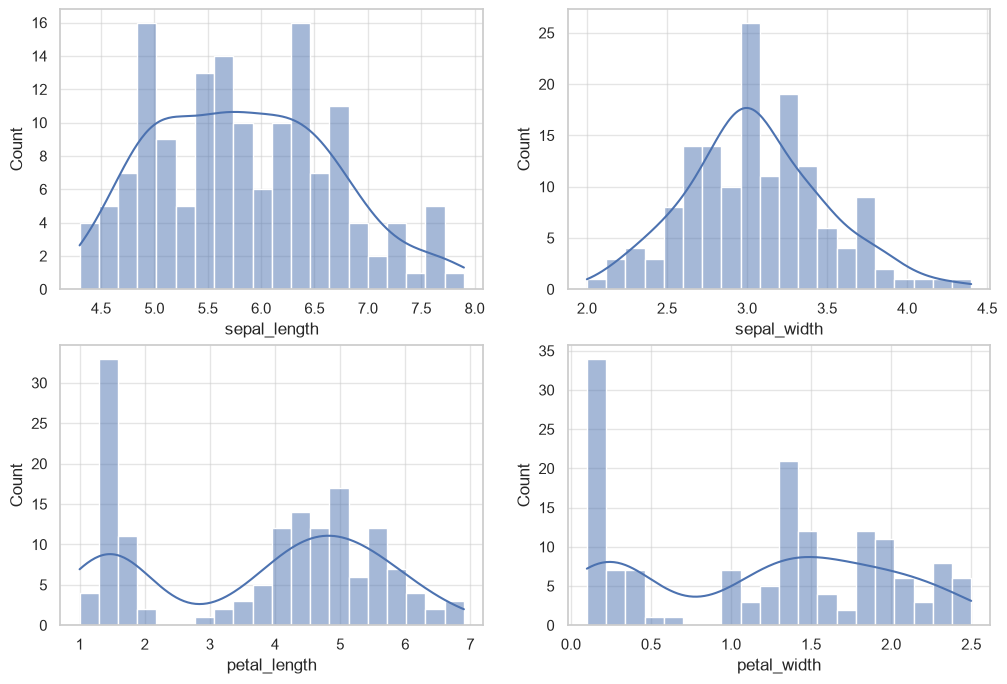

In [33]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=[12, 8])

# axes  차원이라서 풀어줘야 함. axes.flat
# 배열과 배열을 묶어줌- 우리가 할 건 반복문이라/ 차원이 동일해야 함
for ax, column_name in zip(axes.flat, numeric_columns):
    sns.histplot(
        data=df,
        x=column_name,
        bins=20,
        kde=True,
        ax=ax
    )
#품종을 고려하지 않은 ...그래서 다변량 분석을 해봐야 겠다는 결론을 내려야 함

# [0,1,2,3] ['a','b','c','d']

# 상관관계는 이상치에 취약함으로 개별 변수에 있는지 없는지 확인해야 함


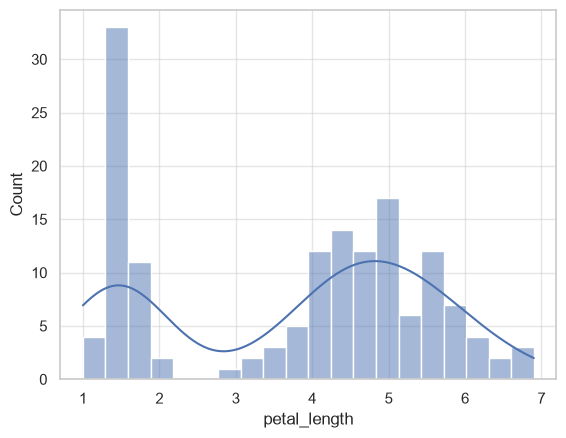

In [34]:
sns.histplot(
    data=df,
    x='petal_length',
    bins=20,
    kde=True
)
plt.show()

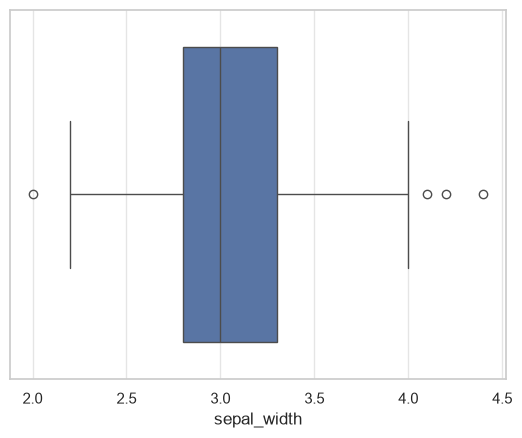

In [50]:
# 상관관계는 이상치에 취약함으로 개별 변수에 있는지 없는지 확인해야 함

sns.boxplot(data=df, x='sepal_width')
plt.show()

# 점은 극단값(최대 최소)

In [37]:
q1 = df['sepal_width'].quantile(0.25)
q3 = df['sepal_width'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1-1.5*iqr
upper_bound = q3+1.5*iqr

print(f'q1 = {q1}')
print(f'3 = {q3}')
print(f'iqr={iqr}')
print(f'lower_bound = {lower_bound}')
print(f'upper_bound = {upper_bound}')


q1 = 2.8
3 = 3.3
iqr=0.5
lower_bound = 2.05
upper_bound = 4.05


In [40]:
outlier= df[
    (df['sepal_width'] < lower_bound)
    |
    (df['sepal_width'] > upper_bound)
]
outlier


,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor


In [41]:
len(outlier)

4

In [61]:
for column_name in numeric_columns:
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df[column_name] < lower_bound) | (df[column_name] > upper_bound)).sum()

    print(column_name, outlier_count)



sepal_length 0
sepal_width 4
petal_length 0
petal_width 0


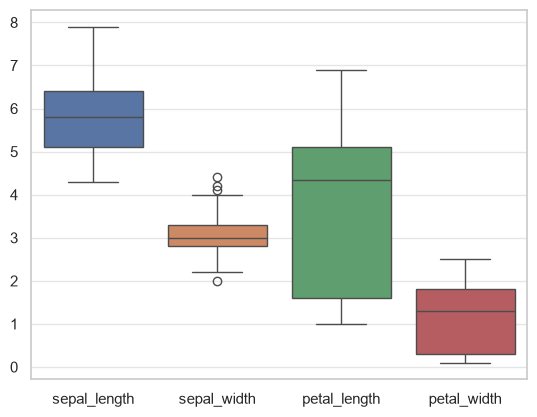

In [63]:
sns.boxplot(
    data=df[numeric_columns],
)

plt.show()

In [ ]:
### 다변량 분석
# - 수치형 + 수치형
# - 범주형 + 수치형


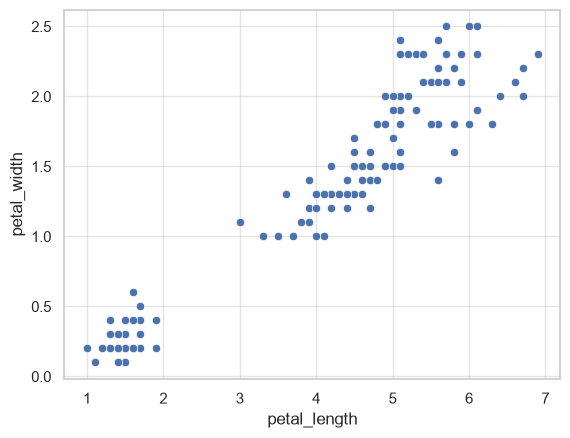

In [55]:
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
)
plt.show()

In [65]:
df[numeric_columns].corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [64]:
correlation= df['petal_length'].corr(df['petal_width'])
print(correlation.round(2))

0.96


## 모델링
### 회귀(Regression)
회귀는 하나 이상 변수의 변화(독립변수X)가 다른 변수(종속변수, Y)에 미치는 영향을 수식으로 모델링하여 추정하는 기법
$Y = WX + b$
가중치*독립변수+

> 회귀: 부모와 자녀의 키 관계를 연구, 부모의 키가 아주 크거나 작아도 자녀의 키는 전체 인구의 평균 크기로 돌아가려는 경향이 있다. 에서 유래가 있음.

## 회귀선(Regression line)
산점도 상에서 흩어져 있는 데이터 포인트(점)들의 전체적인 추세나 경향을 가장 잘 대표하도록 그린 '최적의 선'을 의미

- 손실 함수..->돌려주는 역전파//그대로 순전파(순방향 전파)?

- 테라스?


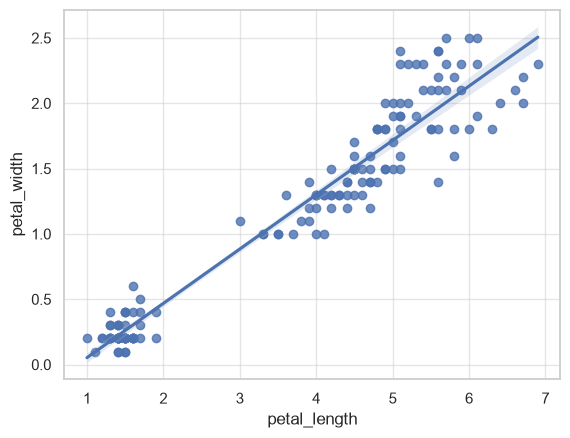

In [66]:
sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
)
plt.show()

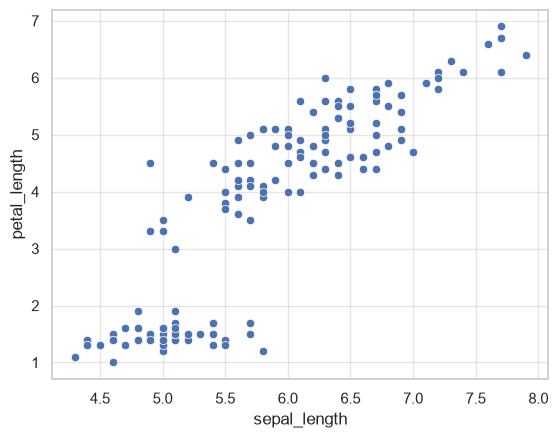

In [67]:
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='petal_length',
)

plt.show()

In [69]:
round(df['sepal_length'].corr(df['petal_length']),2)

np.float64(0.87)

In [73]:
species_mean = df.groupby('species')[numeric_columns].mean().round(2)
species_mean

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


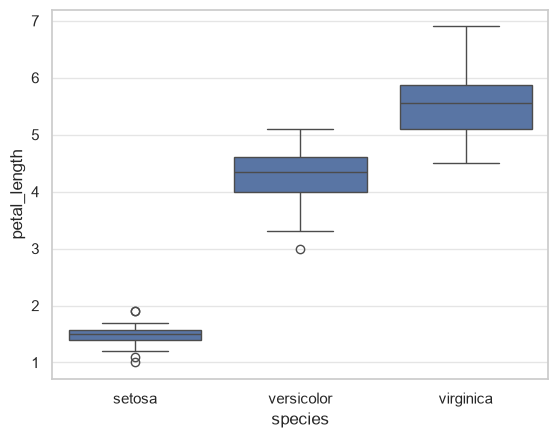

In [74]:
sns.boxplot(
    data=df,
    x='species',
    y='petal_length'
)
plt.show()

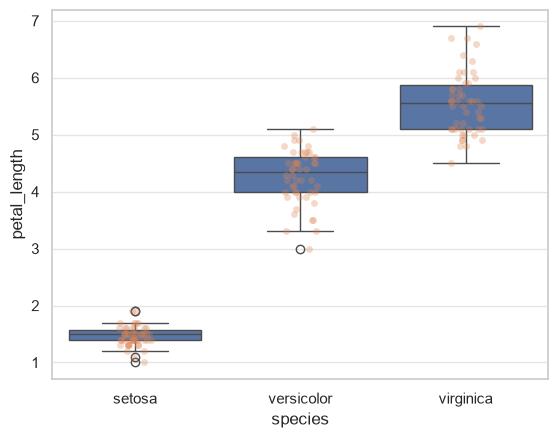

In [75]:
ax = sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
)

sns.stripplot(
    data=df,
    x='species',
    y='petal_length',
    alpha=0.3,
    ax=ax
)

plt.show()

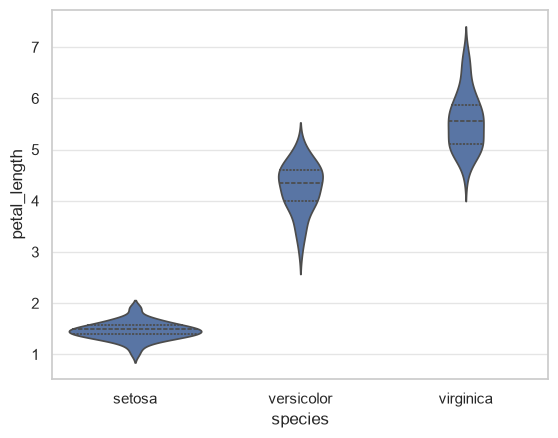

In [76]:
sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    inner='quart'
)

plt.show()

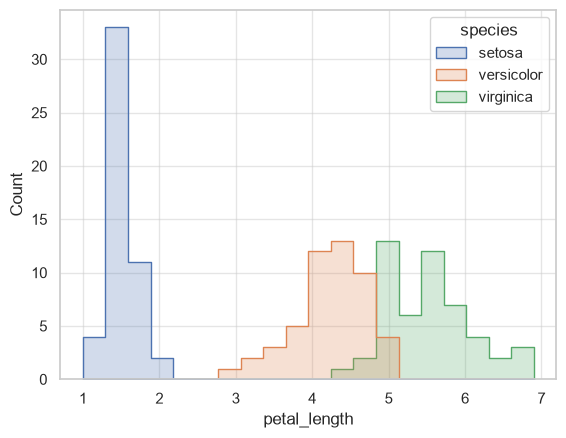

In [79]:
sns.histplot(
    data=df,
    x='petal_length',
    hue='species',
    bins=20,
    element='step'
)
plt.show()

품종별 꽃잎의 너비와 길이의 상관관계(다변량분석)

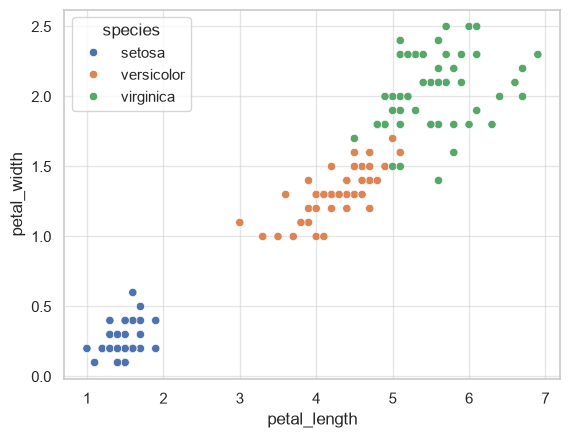

In [80]:
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
)
plt.show()

전체적으로 꽃잎 길이가 너비와 함께 증가하지만 종을 포함하여 확인하니 세 품종이 서로 다른 영역에 위치하고 있는 것을 확인했다.

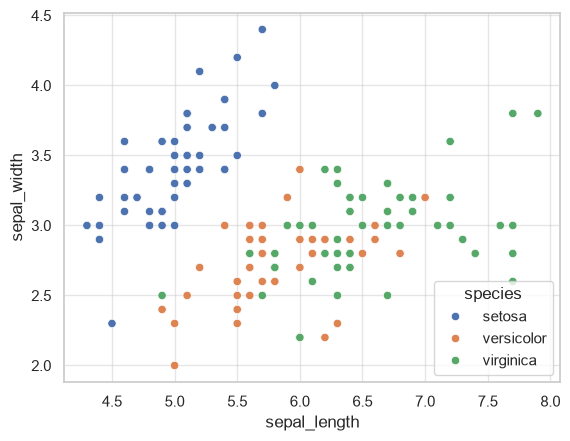

In [81]:
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='sepal_width',
    hue='species',
)
plt.show()

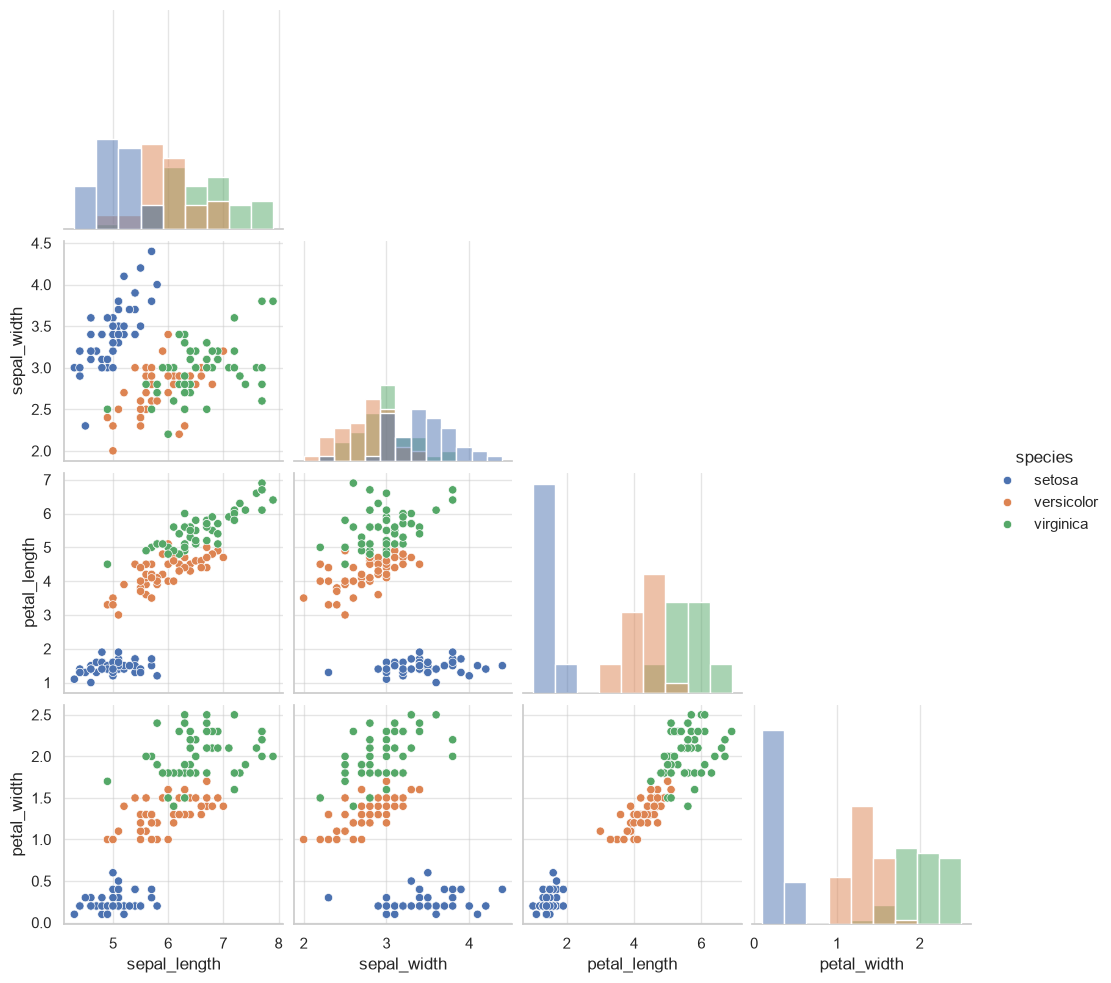

In [84]:
sns.pairplot(
    data=df,
    vars=numeric_columns,
    hue='species',
    diag_kind='hist',
    corner=True,
)
plt.show()
## 실제 관계의 형태를 알 수 있음(산점도)

- 대각선: 품종별 변수 분포를 확인할 때 사용
- 비대각선: 수치형 변수 사이의 관계를 확인
- 색상그룹: 품종이 서로 분리되는 영역이 어디인지 확인
- 겹치는 영역: 품종 구분이 어려운 변수 조합이 무엇인지를 확인

- 각 변수의 분포
- 모든 변수쌍의 관계
- 품종별로 데이터가 어떻게 위치하고 있는지

In [85]:
# fig(그림-전체 그림), ax(개별 변수 다룸-개별 그림) = plt.subplots(튜플 반환)
def test_1():
    return (1,2) # 튜플에 한해서 반환할 때 하나하나 넣어줄 수 있음, 불변이기에 // 자바스크립트, c
a, b = test_1()
print(a)
print(b)

1
2


In [89]:
# 파이썬에서 가능한 것
def test_1():
    return (1,'2') # 원하는 타입 넣을 수 있음
a, b = test_1()
print(a)
print(b)

1
2


In [90]:
def test_1():
    return (A(),B())

class A:
    def call_a(self):
        return 1
class B:
    def call_b(self):
        return 2
a, b = test_1()
print(a.call_a())
print(b.call_b())

1
2


In [92]:
df[numeric_columns] # 베열이기에 데이터프레임이 나옴
corr_matrix = df[numeric_columns].corr().round(2)


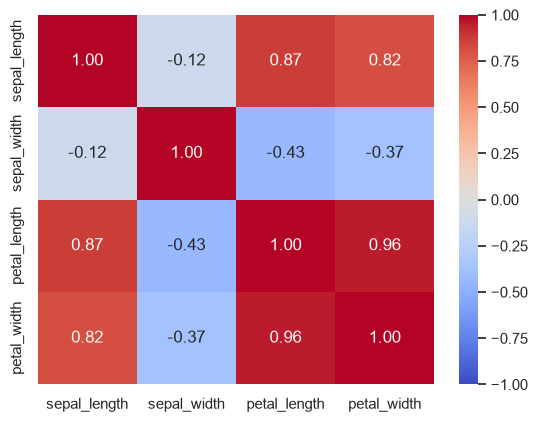

In [96]:
sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    vmax=1,
    vmin=-1,
    center=0,
    cmap='coolwarm',
)
plt.show()

## 관계의 변수를 알 수 있음

- 세 품종은 꽃잎 길이에서 뚜렷한 차이를 보인다
- 꽃잎 길이와 꽃잎 너비는 강한 양의 관계를 갖는다.
- 꽃잎 관련 변수는 꽃받침 관련 변수보다 품종별 구분이 명확하다

### - 세 품종은 꽃잎 길이에서 뚜렷한 차이를 보인다

In [97]:
petal_mean = df.groupby('species')['petal_length'].mean()
petal_mean.round(2)

species
setosa        1.46
versicolor    4.26
virginica     5.55
Name: petal_length, dtype: float64

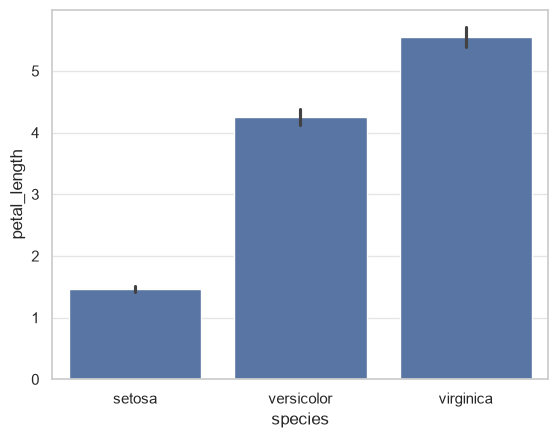

In [98]:
order = petal_mean.index
sns.barplot(
    data=df,
    x='species',
    y='petal_length',
    order=order,
    estimator='mean'
)
plt.show()

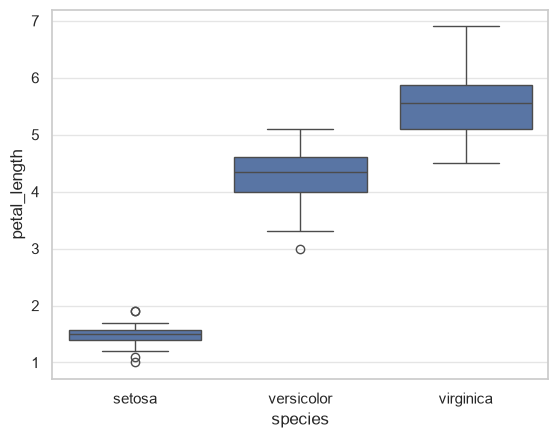

In [99]:
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
)
plt.show()

1. 평균의 차이를 강조: 막대그래프
2. 분포의 차이를 강조: 상자수염그래프, 바이올린 그래프
3. 두 변수간 관계를 강조: 산점도
4. 선형관계를 강조: 회귀선(산점도)

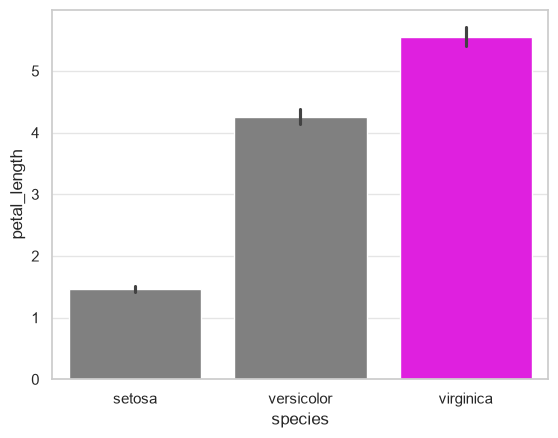

In [102]:
highlight_palette = {
    'setosa': '#808080',
    'versicolor': '#808080',
    'virginica': '#FF00FF'
}
sns.barplot(
    data=df,
    x='species',
    y='petal_length',
    hue='species',
    palette=highlight_palette,
    estimator='mean',
    legend=False,
)
plt.show()